# 04 · Finding the rotation centre

**Audience:** users whose data does not come with a known rotation-axis
shift, or who suspect the stored value is off.

**The symptom of a wrong shift:** arc-shaped / comet-tail artefacts that
sweep around the rotation centre. A perfectly cleaned recon with a
1-pixel shift error will still look wrong.

**Strategy:**

1. **Coarse sweep** over a wide range (e.g. ±25 px) at large steps.
2. **Pick visually** + by `mean stack std` (sharp recons have higher
   variance because edges are intact).
3. **Fine sweep** in a narrow window around the winner.
4. **Confirm** with orthogonal views — a wrong shift breaks them most
   obviously.


In [1]:
# --- Setup ---------------------------------------------------------
%matplotlib inline
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

# Make the MIDAS TOMO Python API importable
MIDAS_TOMO = os.path.expanduser('~/opt/MIDAS/TOMO')
if MIDAS_TOMO not in sys.path:
    sys.path.insert(0, MIDAS_TOMO)
NB_DIR = os.path.join(MIDAS_TOMO, 'notebooks')
if NB_DIR not in sys.path:
    sys.path.insert(0, NB_DIR)

import _phantom as phantom

# Working directory for this notebook's outputs
WORK = os.path.expanduser('~/tomo_notebooks/04_shift')
os.makedirs(WORK, exist_ok=True)
print('Working dir:', WORK)


Working dir: /Users/hsharma/tomo_notebooks/04_shift


## 1 · Synthetic data with a known, non-zero shift

We bake a +3-pixel offset into the projection geometry so we have a
ground truth to recover.


In [2]:
from scipy.ndimage import shift as nd_shift

vol = phantom.make_phantom(64, 64, 64)
angles = np.arange(0, 180, 1.0, dtype=np.float32)
acq = phantom.make_acquisition(vol, angles, add_rings=False)

KNOWN_SHIFT = 3.0
proj_shifted = np.stack([
    nd_shift(acq.projections[i].astype(np.float32), (0, KNOWN_SHIFT),
             order=1).astype(np.uint16)
    for i in range(acq.projections.shape[0])
])
whites = np.stack([acq.whites_before.mean(0), acq.whites_after.mean(0)])
print('Truth shift =', KNOWN_SHIFT)


Truth shift = 3.0


## 2 · Coarse shift sweep

> **Even-shifts rule.** The C engine processes shifts in pairs, so the
> number of shifts in any sweep must be even. `[-8, 7, 1]` gives 16
> shifts (good); `[-8, 8, 1]` gives 17 (would fail).


In [3]:
from midas_tomo_python import run_tomo
recon_coarse = run_tomo(proj_shifted, acq.dark, whites,
                        WORK, angles,
                        shifts=[-8.0, 7.0, 1.0],   # 16 shifts (even)
                        numCPUs=4, doCleanup=0)
print('shape (n_shifts, n_slices, X, Y):', recon_coarse.shape)


Time elapsed in preprocessing: 0.002s.
Version: MIDAS v11.0 (8a155821)
Total number of thetas: 180
We are doing all slices. Total number of slices: 64

          MIDAS TOMO - Configuration Summary
  Data Input:
    Data File       : /Users/hsharma/tomo_notebooks/04_shift/input.bin
    Input Type      : Raw Projections
    Recon Output    : /Users/hsharma/tomo_notebooks/04_shift/output
  Detector:
    Dimensions      : 64 x 64 (X x Y)
  Angles:
    Theta Count     : 180
    Range           : 0.00 to 179.00
  Reconstruction:
    Filter          : 2
    Shift Range     : -8.00 to 7.00 (step 1.00, n=16)
    Slices          : 64
    Auto Centering  : Yes
    Log Projection  : Yes
    Extra Padding   : 0
    Save Separate   : No
  Corrections:
    Ring Removal    : No
    Stripe Removal  : No

Sinograms are a power of 2!
Reading wisdom file fftwf_wisdom_2d_128.txt.
Memory needed per process: 1573050, Total available RAM: 68719476736, MaxNProcs: 43685.
We can run up to 43683 processes.
We wil

## 3 · Score each shift by mean stack std

Sharp reconstructions preserve high-frequency content and therefore
higher per-slice standard deviation. We average across the whole
stack to suppress slice-to-slice variation.


Best coarse shift: -2.00  (truth was +3.00)


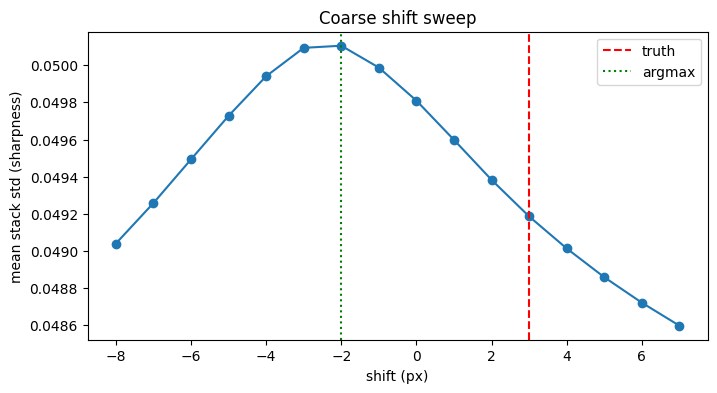

In [4]:
shifts_coarse = np.arange(-8.0, 7.001, 1.0)   # matches the 16 shifts above
score = recon_coarse.std(axis=(2, 3)).mean(axis=1)
best_idx = int(np.argmax(score))
print(f'Best coarse shift: {shifts_coarse[best_idx]:+.2f}  '
      f'(truth was {KNOWN_SHIFT:+.2f})')

plt.figure(figsize=(8, 4))
plt.plot(shifts_coarse, score, 'o-')
plt.axvline(KNOWN_SHIFT, color='r', linestyle='--', label='truth')
plt.axvline(shifts_coarse[best_idx], color='g', linestyle=':',
            label='argmax')
plt.xlabel('shift (px)'); plt.ylabel('mean stack std (sharpness)')
plt.legend(); plt.title('Coarse shift sweep'); plt.show()


## 4 · Visualize the sweep montage at one slice


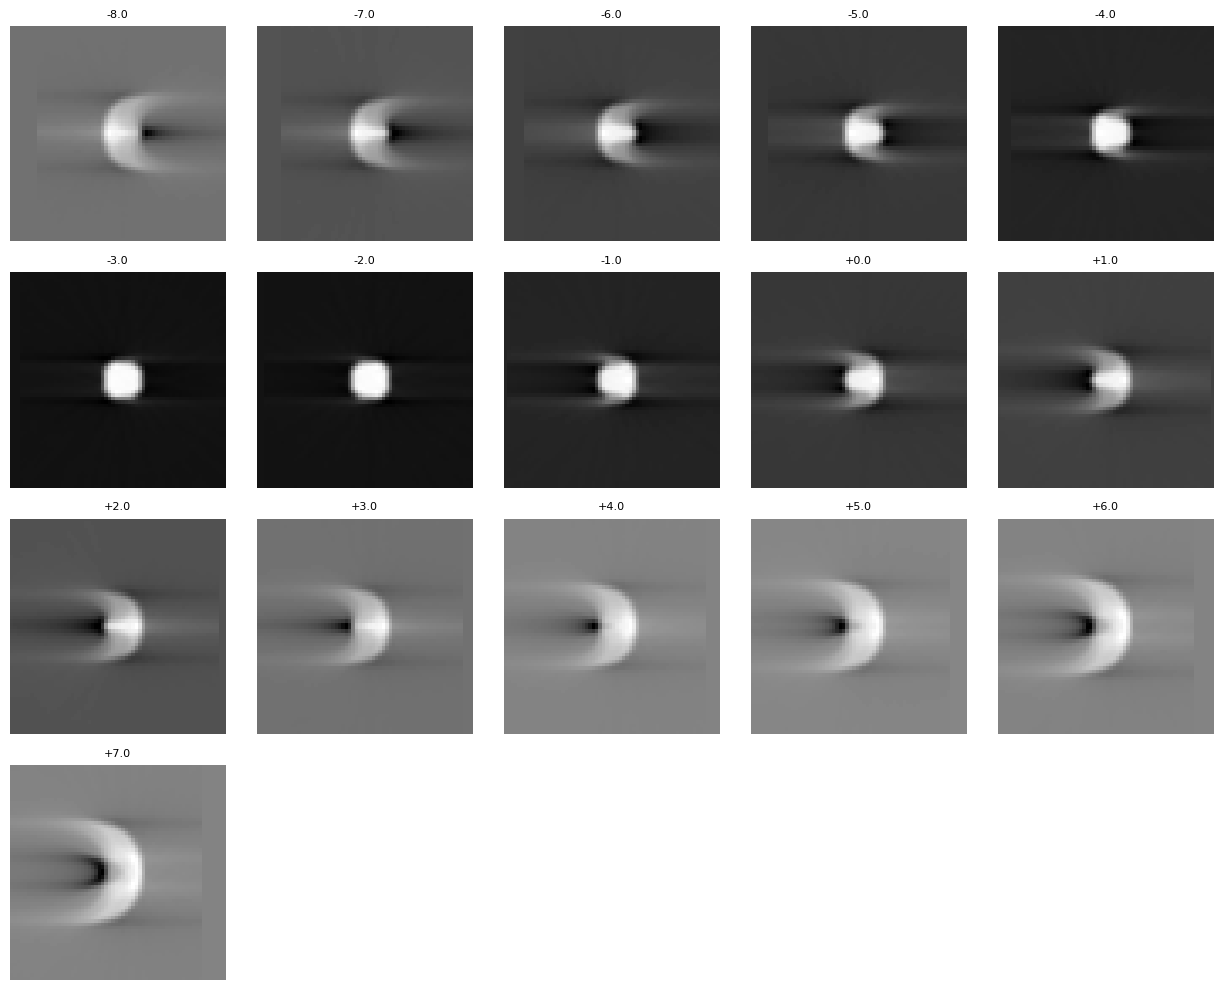

In [5]:
sl = recon_coarse.shape[1] // 2
n = len(shifts_coarse)
cols = 5
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.5),
                         sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()
for i, sv in enumerate(shifts_coarse):
    ax = axes[i]
    ax.imshow(recon_coarse[i, sl], cmap='gray')
    ax.set_title(f'{sv:+.1f}', fontsize=8)
    ax.axis('off')
    if i == best_idx:
        for sp in ax.spines.values():
            sp.set_edgecolor('red'); sp.set_linewidth(3)
for ax in axes[n:]:
    ax.axis('off')
plt.tight_layout(); plt.show()


## 5 · Fine refinement around the winner


Time elapsed in preprocessing: 0.002s.
Version: MIDAS v11.0 (8a155821)
Total number of thetas: 180
We are doing all slices. Total number of slices: 64

          MIDAS TOMO - Configuration Summary
  Data Input:
    Data File       : /Users/hsharma/tomo_notebooks/04_shift/input.bin
    Input Type      : Raw Projections
    Recon Output    : /Users/hsharma/tomo_notebooks/04_shift/output
  Detector:
    Dimensions      : 64 x 64 (X x Y)
  Angles:
    Theta Count     : 180
    Range           : 0.00 to 179.00
  Reconstruction:
    Filter          : 2
    Shift Range     : -2.90 to -1.00 (step 0.10, n=20)
    Slices          : 64
    Auto Centering  : Yes
    Log Projection  : Yes
    Extra Padding   : 0
    Save Separate   : No
  Corrections:
    Ring Removal    : No
    Stripe Removal  : No

Sinograms are a power of 2!
Reading wisdom file fftwf_wisdom_2d_128.txt.
Memory needed per process: 1573050, Total available RAM: 68719476736, MaxNProcs: 43685.
We can run up to 43683 processes.
We wi

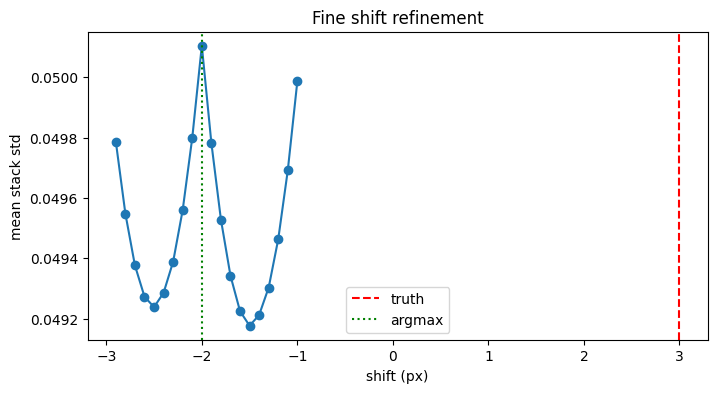

In [6]:
best_coarse = shifts_coarse[best_idx]
# [-0.9, +1.0, 0.1] → 20 shifts (even) — see the rule in §2
recon_fine = run_tomo(
    proj_shifted, acq.dark, whites, WORK, angles,
    shifts=[best_coarse - 0.9, best_coarse + 1.0, 0.1],
    numCPUs=4, doCleanup=0,
)
shifts_fine = np.arange(best_coarse - 0.9, best_coarse + 1.001, 0.1)
score_fine = recon_fine.std(axis=(2, 3)).mean(axis=1)
best_fine_idx = int(np.argmax(score_fine))
print(f'Best fine shift: {shifts_fine[best_fine_idx]:+.2f}  '
      f'(truth: {KNOWN_SHIFT:+.2f})')

plt.figure(figsize=(8, 4))
plt.plot(shifts_fine, score_fine, 'o-')
plt.axvline(KNOWN_SHIFT, color='r', linestyle='--', label='truth')
plt.axvline(shifts_fine[best_fine_idx], color='g', linestyle=':',
            label='argmax')
plt.xlabel('shift (px)'); plt.ylabel('mean stack std')
plt.legend(); plt.title('Fine shift refinement'); plt.show()


## 6 · Confirm with orthogonal views

A wrong shift shows up most obviously in the XZ / YZ cuts —
"duplicated edges" or asymmetric blur means the reconstruction is not
spatially consistent.


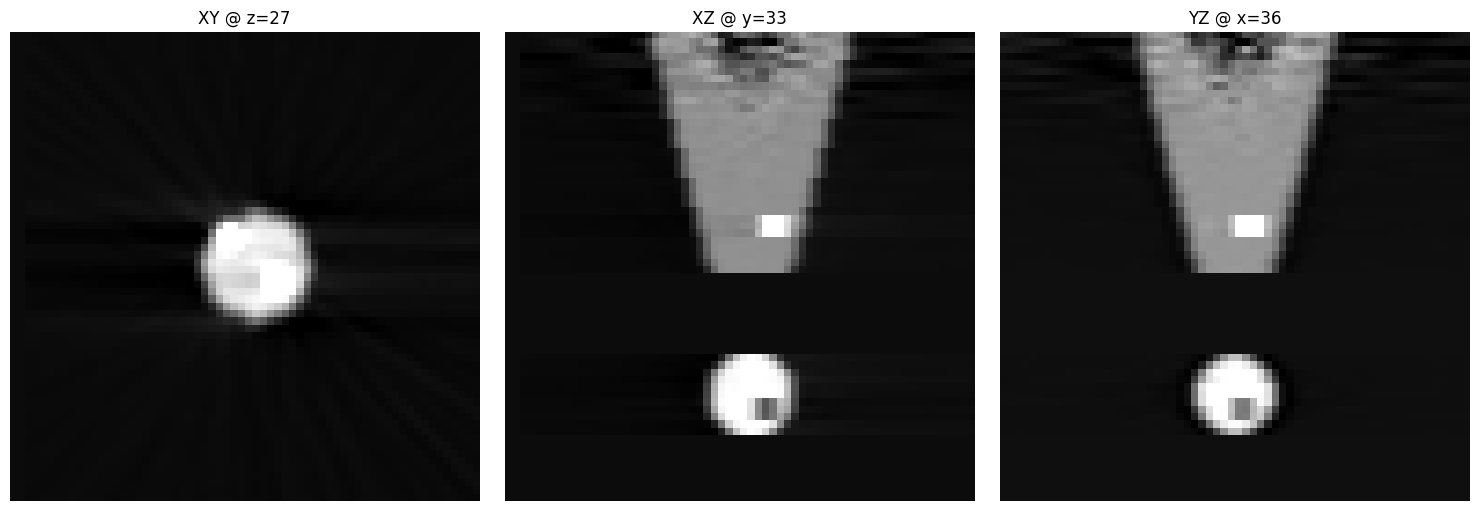

In [7]:
cube_best = recon_fine[best_fine_idx]
zb, yb, xb = np.unravel_index(np.argmax(cube_best), cube_best.shape)
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
for a, im, t in zip(ax,
                    [cube_best[zb], cube_best[:, yb, :], cube_best[:, :, xb]],
                    [f'XY @ z={zb}', f'XZ @ y={yb}', f'YZ @ x={xb}']):
    vmin, vmax = np.percentile(im, 1), np.percentile(im, 99)
    a.imshow(im, cmap='gray', vmin=vmin, vmax=vmax, aspect='equal')
    a.set_title(t); a.axis('off')
plt.tight_layout(); plt.show()


## 7 · No shift estimate at all? Visual scanning is faster than coding

If you start from scratch and have no idea where the centre is:

1. **Sweep ±detector_width / 4** at step = detector_width / 32. That
   gives ~16 reconstructions covering the entire plausible range.
2. **Look at the montage.** Wrong shifts produce obvious arcs; the
   right shift produces a recognisable sample.
3. **Refine** in a 2-pixel window around the visual winner at step
   0.1.

The `mean stack std` heuristic works well **near** the optimum but is
noisy across the coarse range; always cross-check visually.

## 8 · Combining shift + cleanup

Stripe-removal parameters are largely independent of small shift
errors, so the typical workflow is:

1. **Cleanup tuning first** (notebook 03) at a single reasonable shift
   — pick the best `(snr, la, sm)` triple.
2. **Shift sweep next** with that cleanup applied (`doStripeRemoval=1`
   in `run_tomo`).

If you really want the joint best, the C engine supports it: set
`stripeConfigFile` AND a multi-shift `shiftValues` and you get an
`(n_cleanup, n_shifts, n_slices, X, Y)` cube in a single MIDAS_TOMO
call. See §4.3 of the manual.
